In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
from prf_expect.utils import io
from prf_expect.utils.viz import desaturate_palette, sample_cmap, cm_to_inch
from matplotlib.colors import LightSource
from scipy.stats import t
from matplotlib import rc
from matplotlib import font_manager
import matplotlib.pyplot as plt

font_dirs = ['/tank/shared/software/fonts/arial']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

rc('pdf', fonttype=42, use14corefonts=False)
rc('axes', linewidth=0.5)
rc('font',**{'family':'Arial'})
rc('text', usetex=False)
rc('xtick', labelsize=6)
rc('ytick', labelsize=6)
rc('axes', labelsize=7)
rc('legend', fontsize=6)

plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['xtick.minor.size'] = 1
plt.rcParams['ytick.minor.size'] = 1

# set up figure parameters
markeredgecolor = ".4"
bar_linewidth = 0.5
bar_alpha = 0.7
xticks_rotation = 45
marker = "s"
marker_edge_width = 0.5
markersize = 4/2.54
errorbar_linewidth = 0.5
errorbar_capsize = 0.7/2.54
errorbar_capthick = 0.5

In [2]:
save_figs = True

In [3]:
figure_result_dir = Path("/tank/nwa201/projects/pRF_expect/code/pRF_expect_analysis/prf_expect/analysis/figures")

In [4]:
def load_tsv(data_path):
    """
    Load a TSV file and return its content as a numpy array.
    Parameters
    ----------
    data_path : str
        Path to the TSV file.
    Returns
    -------
    data : pandas.DataFrame
        DataFrame containing the content of the TSV file.
    """
    data = pd.read_csv(data_path, sep="\t", header=0)
    return data


def load_behavioral_data(data_path):
    """
    Load a behavioral data file and return its content as a pandas DataFrame.
    Parameters
    ----------
    data_path : str
        Path to the behavioral data file.
    Returns
    -------
    data : pandas.DataFrame
        DataFrame containing the content of the behavioral data file.
    """
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"Behavioral data file not found: {data_path}")
    data = load_tsv(data_path)
    return data

In [5]:
def calculate_response_times(dot_color_switch_time, response_onsets):
    """
    Calculate response times after dot color switches.
    
    Parameters
    ----------
    dot_color_switch_time : np.ndarray
        Array of dot color switch times.
    response_onsets : np.ndarray
        Array of response onsets.
    
    Returns
    -------
    response_times : np.ndarray
        Array of response times after each dot color switch.
    """
    response_times = []
    for switch_time in dot_color_switch_time:
        response_after_switch = response_onsets[response_onsets > switch_time]
        if len(response_after_switch) == 0 or (response_after_switch[0] - switch_time) > 1.5:
            response_times.append(np.nan)
        else:
            response_times.append(response_after_switch[0] - switch_time)

    return np.array(response_times)

def calc_hit_rate(response_times):
    """
    Calculate hit rate from response times.
    
    Parameters
    ----------
    response_times : np.ndarray
        Array of response times after each dot color switch.
    
    Returns
    -------
    hit_rate : float
        Proportion of dot color switches that were detected (responded to within 2 seconds).
    """
    hits = np.sum(~np.isnan(response_times))
    total_switches = len(response_times)
    return hits / total_switches if total_switches > 0 else 0


In [6]:
str2int = lambda x: int(x)

def str2tuple(s):
    l = list(map(str, s.strip("()").split(",")))
    l2 = []
    for i in range(len(l)):
        e = (l[i].strip("'"))
        e = (e.strip(' '))
        e = (e.strip("'"))
        l2.append(e)
    return tuple(l2)

In [7]:
# Load settings from json file
settings = io.load_settings()
path_pe_runs_order = Path("/tank/nwa201/projects/pRF_expect/code/pRF_expect_analysis/prf_expect/run_list/PE_runs_order.tsv")
pe_runs_order = pd.read_csv(path_pe_runs_order, sep="\t")

df = pd.DataFrame(columns=["subject", "run", "task", "hit_rate", "response_times"])

for subject in ["sub-001", "sub-002", "sub-004", "sub-005", "sub-007", "sub-009", "sub-012"]:
    hit_rates = []
    for run in ["1","2","3","4","5","6"]:
        # Determine the task based on the run number
        if run in ["1", "3", "5"]:
            task = "pRF"
            task_name = "pRF"
            task_run = int((str2int(run)+1)/2)
            task_run_str = str(task_run)
            # continue
        elif run in ["2", "4", "6"]:
            task = "PE"
            task_name = "PE"
            task_run = int((str2int(run))/2)
        task_run_str = str(task_run)
        
        if task == "PE":
            pe_runs_order_sub = str2tuple(pe_runs_order.loc[task_run, str(str2int(subject.split("-")[1]))])

        beh_dir = os.path.join(settings["general"]["data_dir"], "data", "sourcedata", subject, "ses-1", "logs", f"{subject}_ses-1_run-{run}_Logs")
        beh_file = os.path.join(beh_dir, f"{subject}_ses-1_run-{run}_events.tsv")
        dot_color_switch_time_file = os.path.join(beh_dir, f"{subject}_ses-1_run-{run}_DotSwitchColorTimes.npy")
        dot_color_switch_time = np.load(dot_color_switch_time_file)
        
        first_part_dotchange_onset = dot_color_switch_time[dot_color_switch_time < 125*1.6] # First part of the run (first 125 TRs)
        second_part_dotchange_onset = dot_color_switch_time[(dot_color_switch_time >= 125*1.6) & (dot_color_switch_time < 250*1.6)] # Second part of the run (second 125 TRs)
        third_part_dotchange_onset = dot_color_switch_time[dot_color_switch_time >= 250*1.6] # Third part of the run (last 125 TRs)
        
        # Load behavioral data
        behavioral_data = load_behavioral_data(beh_file)
        response_onsets = behavioral_data['onset'].values
        first_part_response_onsets = response_onsets[response_onsets < 125*1.6]
        second_part_response_onsets = response_onsets[(response_onsets >= 125*1.6) & (response_onsets < 250*1.6)]
        third_part_response_onsets = response_onsets[response_onsets >= 250*1.6]

        # Calculate response times for each part of the run
        first_part_response_times = calculate_response_times(first_part_dotchange_onset, first_part_response_onsets)
        second_part_response_times = calculate_response_times(second_part_dotchange_onset, second_part_response_onsets)
        third_part_response_times = calculate_response_times(third_part_dotchange_onset, third_part_response_onsets)

        first_part_hit_rate = calc_hit_rate(first_part_response_times)
        second_part_hit_rate = calc_hit_rate(second_part_response_times)
        third_part_hit_rate = calc_hit_rate(third_part_response_times)

        df_subrun_1 = pd.DataFrame({
            "subject": subject,
            "run": run,
            "condition": [pe_runs_order_sub[0] if task == "PE" else "pRF"],
            "hit_rate": first_part_hit_rate,
            "response_times": np.nanmean(first_part_response_times)
        }, index=[0])
        df_subrun_2 = pd.DataFrame({
            "subject": subject,
            "run": run,
            "condition": [pe_runs_order_sub[1] if task == "PE" else "pRF"],
            "hit_rate": second_part_hit_rate,
            "response_times": np.nanmean(second_part_response_times)
        }, index=[0])
        df_subrun_3 = pd.DataFrame({
            "subject": subject,
            "run": run,
            "condition": [pe_runs_order_sub[2] if task == "PE" else "pRF"],
            "hit_rate": third_part_hit_rate,
            "response_times": np.nanmean(third_part_response_times)
        }, index=[0])
        df = pd.concat([df, df_subrun_1, df_subrun_2, df_subrun_3], ignore_index=True)



Loading settings from /tank/nwa201/projects/pRF_expect/code/pRF_expect_analysis/prf_expect/settings.yml


/tmp/ipykernel_2391132/2461333193.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, df_subrun_1, df_subrun_2, df_subrun_3], ignore_index=True)


In [8]:
df

,subject,run,task,hit_rate,response_times,condition
0,sub-001,1,NaN,1.000000,0.248430,pRF
1,sub-001,1,NaN,1.000000,0.268876,pRF
2,sub-001,1,NaN,1.000000,0.267542,pRF
3,sub-001,2,NaN,1.000000,0.259644,o
4,sub-001,2,NaN,1.000000,0.271181,v
...,...,...,...,...,...,...
121,sub-012,5,NaN,1.000000,0.310536,pRF
122,sub-012,5,NaN,0.982456,0.322925,pRF
123,sub-012,6,NaN,0.982456,0.305453,v
124,sub-012,6,NaN,1.000000,0.294887,e


In [9]:
pivot_df = df.pivot_table(index=["subject", "condition"],  values=["hit_rate", "response_times"], aggfunc='mean').reset_index()

In [10]:
pivot_df

,subject,condition,hit_rate,response_times
0,sub-001,e,0.994152,0.251673
1,sub-001,o,1.000000,0.276832
2,sub-001,pRF,0.998051,0.258018
3,sub-001,v,1.000000,0.273371
4,sub-002,e,1.000000,0.258407
5,sub-002,o,1.000000,0.268202
6,sub-002,pRF,0.998051,0.263107
7,sub-002,v,1.000000,0.282706
8,sub-004,e,1.000000,0.309439
9,sub-004,o,1.000000,0.276383


In [11]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('hit_rate ~ C(subject) + C(condition)', data=pivot_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# t-test for hit_rate between PE and non-PE conditions
from scipy.stats import ttest_ind
# t-test for hit_rate between conditions
conditions = pivot_df['condition'].unique()
# compare between all conditions
for i in range(len(conditions)):
    for j in range(i + 1, len(conditions)):
        cond1 = pivot_df[pivot_df['condition'] == conditions[i]]
        cond2 = pivot_df[pivot_df['condition'] == conditions[j]]
        t_stat, p_value = ttest_ind(cond1['hit_rate'], cond2['hit_rate'])
        print(f"Comparison between {conditions[i]} and {conditions[j]}: T-statistic: {t_stat:.3f}, P-value: {p_value:.3f}")

                sum_sq    df         F    PR(>F)
C(subject)    0.000038   6.0  0.646512  0.692401
C(condition)  0.000010   3.0  0.348837  0.790436
Residual      0.000175  18.0       NaN       NaN
Comparison between e and o: T-statistic: -0.612, P-value: 0.552
Comparison between e and pRF: T-statistic: 0.240, P-value: 0.814
Comparison between e and v: T-statistic: 0.408, P-value: 0.690
Comparison between o and pRF: T-statistic: 1.188, P-value: 0.258
Comparison between o and v: T-statistic: 0.866, P-value: 0.403
Comparison between pRF and v: T-statistic: 0.311, P-value: 0.761


In [12]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('response_times ~ C(subject) + C(condition)', data=pivot_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# t-test for response_times between PE and non-PE conditions
from scipy.stats import ttest_ind
# t-test for response_times between conditions
conditions = pivot_df['condition'].unique()
# compare between all conditions
for i in range(len(conditions)):
    for j in range(i + 1, len(conditions)):
        cond1 = pivot_df[pivot_df['condition'] == conditions[i]]
        cond2 = pivot_df[pivot_df['condition'] == conditions[j]]
        t_stat, p_value = ttest_ind(cond1['response_times'], cond2['response_times'])
        print(f"Comparison between {conditions[i]} and {conditions[j]}: T-statistic: {t_stat:.3f}, P-value: {p_value:.3f}")

                sum_sq    df          F    PR(>F)
C(subject)    0.013675   6.0  16.741902  0.000002
C(condition)  0.000674   3.0   1.649886  0.213270
Residual      0.002450  18.0        NaN       NaN
Comparison between e and o: T-statistic: -0.145, P-value: 0.887
Comparison between e and pRF: T-statistic: 0.623, P-value: 0.545
Comparison between e and v: T-statistic: -0.227, P-value: 0.825
Comparison between o and pRF: T-statistic: 0.857, P-value: 0.408
Comparison between o and v: T-statistic: -0.079, P-value: 0.939
Comparison between pRF and v: T-statistic: -1.035, P-value: 0.321


In [13]:
pivot_df

,subject,condition,hit_rate,response_times
0,sub-001,e,0.994152,0.251673
1,sub-001,o,1.000000,0.276832
2,sub-001,pRF,0.998051,0.258018
3,sub-001,v,1.000000,0.273371
4,sub-002,e,1.000000,0.258407
5,sub-002,o,1.000000,0.268202
6,sub-002,pRF,0.998051,0.263107
7,sub-002,v,1.000000,0.282706
8,sub-004,e,1.000000,0.309439
9,sub-004,o,1.000000,0.276383


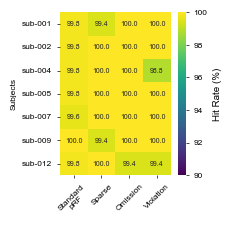

In [18]:
# make a subplot of the hit rates and response times
# ax1: heatmap plot of the hit rates, x-axis:conditions, y-axis: subjects
# ax2: barplot of the response times, show three different conditions, each condition including 7 subjects
import matplotlib.pyplot as plt
import seaborn as sns

# Create a grid of subplots
fig, ax1 = plt.subplots(figsize=cm_to_inch(6, 6))
# Create pivot tables for plotting
hit_rate_pivot = pivot_df.pivot(index="subject", columns="condition", values="hit_rate")
desired_order = ['pRF', 'e', 'o', 'v']  # or whatever order you want
hit_rate_pivot = hit_rate_pivot[desired_order]

response_times_pivot = pivot_df.pivot(index="subject", columns="condition", values="response_times")

# Plot hit rates as a heatmap
sns.heatmap(hit_rate_pivot * 100, annot=True, fmt=".1f", cmap="viridis", ax=ax1, vmin=90, vmax=100, cbar_kws={'label': 'Hit Rate (%)'}, annot_kws={"size": 6})
# change font size of the text in the heatmap
for text in ax1.texts:
    text.set_fontsize(5)
# ax1.set_title("Hit Rates by Subject and Condition")
ax1.set_xlabel("")
ax1.set_ylabel("Subjects", fontsize=6)
# y ticks should be horizontal
ax1.set_yticklabels(hit_rate_pivot.index, rotation=0)
ax1.set_xticklabels(["Standard\npRF", "Sparse", "Omission", "Violation"], rotation=xticks_rotation, fontsize=6)
plt.tight_layout()

if save_figs:
    ax1.figure.savefig(figure_result_dir.joinpath(f"group_beh-performance_accuracy.pdf"), bbox_inches="tight", dpi=600)


/tmp/ipykernel_2391132/3078228857.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(["Standard\npRF", "Sparse", "Omission", "Violation"], rotation=45, fontsize=6)


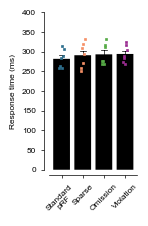

In [15]:
from matplotlib.patches import FancyBboxPatch

# Plot response times as a barplot with the same style
fig, ax2 = plt.subplots(figsize=cm_to_inch(4, 6))
pivot_df_ms = pivot_df.copy()
pivot_df_ms['response_times'] = pivot_df_ms['response_times'] * 1000  # Convert to ms

# Create the barplot with black color like the reference
bars = sns.barplot(data=pivot_df_ms, x="condition", y="response_times", errorbar="se", 
                  color="black", ax=ax2, err_kws={'color': 'black', 'linewidth': 0.5}, 
                  capsize=errorbar_capsize, order=['pRF', 'e', 'o', 'v'])

sns.despine(offset=4)
ax2.set_xlabel("")
ax2.set_ylabel("Response time (ms)", fontsize=6)
ax2.set_xticklabels(["Standard\npRF", "Sparse", "Omission", "Violation"], rotation=45, fontsize=6)
ax2.set_ylim(0, 400)  # Set y-axis limit to 0-400

# Apply fancy rounded corners to bars
new_patches = []
for patch in reversed(ax2.patches):
    bb = patch.get_bbox()
    color = patch.get_facecolor()
    p_bbox = FancyBboxPatch((bb.xmin, bb.ymin),
                            abs(bb.width), abs(bb.height),
                            boxstyle="round,pad=-0.0040,rounding_size=0.08",
                            ec="none", fc=color,
                            mutation_aspect=0.2
                            )
    patch.remove()
    new_patches.append(p_bbox)

for patch in new_patches:
    ax2.add_patch(patch)

# Add individual subject data points
subjects = pivot_df_ms['subject'].unique()
conditions = ['pRF', 'e', 'o', 'v']
norm_subID = np.linspace(0, 1, len(subjects))

# make a palette with 4 colors
# Create an array with the colors you want to use
colors = ["#2f708e", "#f69067", "#56ab46", "#9b2c91"]
customparamPalette = sns.color_palette(sns.color_palette(colors),)
# sns.color_palette(customparamPalette)
customparamPalette_sampled = sample_cmap(customparamPalette, len(colors))

for icond, condition in enumerate(conditions):
    for isubject, subject in enumerate(subjects):
        pos = icond + (norm_subID[isubject]-0.5)*0.2
        mean_data = pivot_df_ms[(pivot_df_ms.condition==condition) & (pivot_df_ms.subject==subject)]["response_times"].values[0]
        ax2.plot(pos, 
                mean_data, 
                marker=marker, 
                markeredgecolor=customparamPalette_sampled[icond], 
                markerfacecolor=customparamPalette_sampled[icond],
                markeredgewidth=marker_edge_width,
                markersize=markersize,
                clip_on=False,
        )

plt.tight_layout()
plt.show()

if save_figs:
    ax2.figure.savefig(figure_result_dir.joinpath(f"group_beh-performance_responsetime.pdf"), bbox_inches="tight", dpi=600)